# Assignment 2

I have designed this document so the 3 main sections should be runnable individually. 

Functions in Section 3 which are shared with section two have been renamed with the suffix "_3" as requested. 

Function calls that take a significant amount of time have been commented out and a render has been embedded as an image file below that code.

The "Appendix" section contains code I was experimenting with. I am not expecting it to be looked at.

Python version: 3.12.1

Libraries required: numpy, matplotlib, scipy

## Section 1

We will study the following set of second-order differential equations:
$$
\begin{align}
\ddot{x}& = y^2 - x^2 -x \\
\ddot{y}& = 2xy -y
\end{align}
$$

##### Task 1.1

In order to work with these equations, we are going to recast them into *first-order form*. To do this we write the equations in the system below:
$$
\begin{align}
\dot{x} = p ~~~~~~~~~ \dot{p}& = y^2 - x^2 -x \\
\dot{y} = q ~~~~~~~~~ \dot{q}& = 2xy - y
\end{align}
$$

A solution for these first-order equations is written as $\mathbf{u}(t) = [x(t), y(t), p(t), q(t)]$ for some initial conditions $\mathbf{u}_0 = [x_0, y_0, p_0, q_0]$. This solution is called an *integral curve* of the equation.

##### Task 1.2: Energy

We can define some functions of $x, y, p, q$ that may have some interesting properties for our system:

1. The *potential energy function* $V(x, y)$ is defined by 
$$
V(x, y) = \frac{1}{2}x^2 + \frac{1}{2}y^2 - xy^2 + \frac{1}{3}x^3
$$
2. The *kinetic energy function* $T(p, q)$ is defined by
$$
T(p, q) = \frac{1}{2}p^2 + \frac{1}{2}q^2
$$
3. The *total energy function* E(x, y, p, q) is the sum of these two functions
$$
E(x, y, p, q) = V(x, y) + T(p, q)
$$


We wish to show that 

$$
\dot{p} = - \left . \frac{\partial V}{\partial x} \right |_{y} ~~~~~~~~~~~~ 
\dot{q} = - \left . \frac{\partial V}{\partial y} \right |_{x}.
$$

First we find the two partial derivatives of $V$:
$$
\begin{align}
\frac{\partial V}{\partial x} &= x- y^2 + x ^2 \\
\frac{\partial V}{\partial y} &= y - 2xy
\end{align}
$$

Then we see:

$$
\begin{align}
- \left . \frac{\partial V}{\partial x} \right |_{y} &= y^2 - x^2 - x = \dot{p}\\
- \left . \frac{\partial V}{\partial y} \right |_{x} &= 2xy - y = \dot{q}
\end{align}
$$

as required. Hence, we need to show that $\dot{E} = 0$, that is, there is no change in total energy along a trajectory. 

To do this, we are going to use the chain rule, roughly: the change in $E$ is the sum of the changes in each of it's component variables. Mathematically this means:
$$
\dot{E} = \frac{\partial E}{\partial x}\dot{x} + \frac{\partial E}{\partial y}\dot{y} + \frac{\partial E}{\partial p}\dot{p} + \frac{\partial E}{\partial q}\dot{q}
$$

We compute $\frac{\partial E}{\partial x}$, $\frac{\partial E}{\partial y}$, $\frac{\partial E}{\partial p}$ and $\frac{\partial E}{\partial q}$:

$$
\begin{alignat}{2}
\frac{\partial E}{\partial x} &= x - y^2 + x^2 \quad\quad\quad &\frac{\partial E}{\partial p} = p \\
\frac{\partial E}{\partial y} &= y - 2xy       \quad\quad\quad &\frac{\partial E}{\partial q} = q
\end{alignat}
$$

Plugging in we see

$$
\dot{E} = (x - y^2 + x^2)p + (y - 2xy)q + p(y^2 -x^2 -x) + q(2xy - y) = 0
$$

as required.

##### Task 1.3: Complex variables and symmetry

We will now suppose a complex variable $z$ defined using the existing variables $x$ and $y$: $z = x + iy$. We are going to show our system of coupled ODEs can be expressed as one ODE in this complex variable. Note that $\dot{z} = \dot{x} + i\dot{y}$ and $\ddot{z} = \ddot{x} + i\ddot{y}$. 

We consider the expression $-z - \bar{z}^2$:

$$
\begin{align}
-z - \bar{z}^2 &= -(x + iy) - (x - iy)^2 \\
&= -(x + x^2 - y^2) - (y - 2xy)i \\
&= \ddot{x} + \ddot{y}i \\
&= \ddot{z}
\end{align}
$$

So we have made the interesting discovery that $\ddot{z} = -z - \bar{z}^2$. We can also rewrite the equations $V$ and $T$ in terms of $z$:

$$
\begin{align}
V &= \frac{1}{2}x^2 + \frac{1}{2}y^2 - xy^2 + \frac{1}{3}x^3 \\
&= \frac{1}{2}(x^2 + y^2) + \frac{1}{3}(x^3 - 3xy^2) \\
&= \frac{1}{2}(\sqrt{x^2 + y^2})^2 + \frac{1}{3}\operatorname{Re}(x^3 + 3x^2yi- 3xy^2 - y^3i)\\
&= \frac{1}{2}|z|^2 + \frac{1}{3}\operatorname{Re}(z^3)~

\end{align}
$$

as required. For $T$, note $\dot{z} = p + iq$.

$$
\begin{align}
T &= \frac{1}{2}p^2 + \frac{1}{2}q^2 \\
&= \frac{1}{2}(p^2 + q^2) \\
&= \frac{1}{2}(\sqrt{p^2 + q^2})^2 \\
&= \frac{1}{2}|\dot{z}|^2
\end{align}
$$

as required. 

Now define a new complex variable $w = e^{2\pi / 3 i}z$. As $ \operatorname{arg} (w) = 2\pi / 3$ and $|w| = 1$, we can interpret multiplication of $w$ on a complex number as a rotation by $2\pi / 3$ radians in the anti-clockwise direction. We also see it is the case for our functions $V$ and $T$ that:

$$
\begin{align}
V(w) &= \frac{1}{2}| e^{2\pi / 3 i}z| ^2 + \frac{1}{3} \operatorname{Re}( (e^{2\pi / 3 i}z)^3) \\
&= \frac{1}{2}(|e^{2 \pi / 3 i}||z|)^2 + \frac{1}{3}\operatorname{Re} (e^{2\pi i}z^3) \\
&= \frac{1}{2}|e^{2 \pi / 3 i}|^2|z|^2 + \frac{1}{3} \operatorname{Re} (1 \times z^3) \\
&= \frac{1}{2}|z|^2 + \frac{1}{3} \operatorname{Re}(z^3) = V(z)
\end{align}
$$

and for $T(w)$, note $\dot{w} = e^{2 \pi / 3 i}\dot{z}$:

$$
\begin{align}
T(w) &= \frac{1}{2}| e^{2 \pi / 3 i}\dot{z}|^2\\
&= \frac{1}{2}|e^{2\pi / 3 i}|^2|\dot{z}|^2 \\
&= \frac{1}{2}| \dot{z}|^2
\end{align}
$$

Geometrically, the results $V(z) = V(w)$ and $T(z) = T(w)$ implies that the potential energy of the system is the same under a rotation of $2\pi/3$. This also implies that the dynamical system itself must also have this symmetry. Given a valid trajectory $(x_1(t), y_1{t})$ we can create two new valid trajectories by using the rotation matrix of $2\pi/3$ and $-2\pi/3$, giving:
$$
\begin{align}
(x_2(t), y_2(t)) &= \left (-\frac{1}{2}x_1 - \frac{\sqrt{3}}{2}y_1, \frac{\sqrt{3}}{2}x_1 - \frac{1}{2}y_1 \right ) \\
(x_3(t), y_3(t)) &= \left (-\frac{1}{2}x_1 + \frac{\sqrt{3}}{2}y_1, - \frac{\sqrt{3}}{2} x_1 - \frac{1}{2} y_1 \right)
\end{align}
$$

respectively.

##### Task 1.4: Critical points

We solve 

$$
\begin{align}
\frac{\partial V}{\partial x} &= x - y^2 + x^2 = 0  \\
\frac{\partial V}{\partial y} &= y - 2xy = 0
\end{align}
$$

and find the stationary points $(0, 0)$, $(\frac{1}{2}, \pm \frac{\sqrt{3}}{2})$ and $(-1, 0)$. These critical points are where the potential energy of the system is not changing. Logically, for this to happen, the trajectory cannot be moving as this would imply the existence of at least some potential energy. Therefore when we are at the stationary points of the potential function we must be at the stationary point on the trajectory. 

$(-1, 0)$, $(\frac{1}{2}, \pm \frac{\sqrt{3}}{2})$ are saddle points. $(0, 0)$ is a local minimum point.

##### Task 1.5: Special contours

The potential $V(x, y)$ takes a constant value along the line $x = 1/2$ we show this by substituting the value $x=1/2$ into the equation:

$$
\begin{align}
V(\frac{1}{2}, y) &= \frac{1}{8} + \frac{1}{2}y^2 - \frac{1}{2}y^2 + \frac{1}{24} \\
&= \frac{1}{6} = E_0
\end{align}
$$

We've commented on the fact that the function $V$ has symmetry under rotation by $2\pi /3$. We can use that to find two more lines that have constant value $E_0$. To do this we find an equation in terms of $(x', y')$ for $\theta = \pm 2 \pi /3$, which involves taking the inverse of the rotation matrix.

$$
\begin{align}
&\begin{pmatrix}
x' \\ y'
\end{pmatrix} =
\begin{pmatrix}
\cos \theta & - \sin \theta \\ \sin \theta & \cos \theta
\end{pmatrix}
\begin{pmatrix}
\frac{1}{2} \\ y
\end{pmatrix} \\
\implies & x' \cos \theta + y' \sin \theta = \frac{1}{2}
\end{align}
$$

Plugging in our two theta values give the equations $x = \sqrt{3}y -1$ and $x = -\sqrt{3}y -1$.

## Section 2

##### Task 2.1: Contour plot

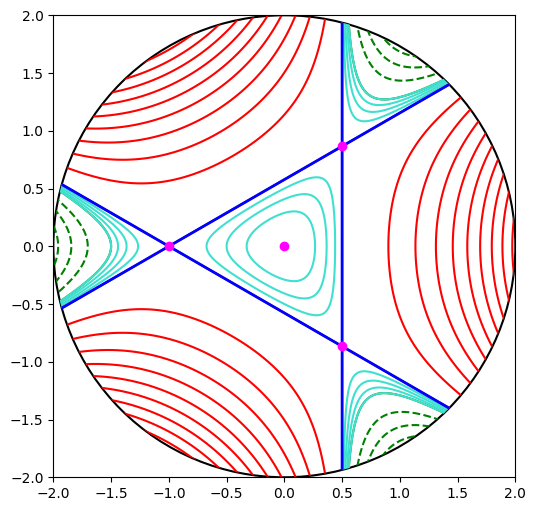

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def V(x: float, y: float) -> float:
    """Potential function"""
    return 0.5*x**2 + 0.5*y**2 - x*y**2 + (1/3)*x**3


def draw_contours(R: float=2, n: int=500):
    """
    Draws contours of the potential function above, with formatting
    requested. Critical points are also highlighted.

    :param float R: Radius of the circle to clip contours to
    :param int n: Number of points in each dimension for the grid
    """

    # Create grid and V values
    x = np.linspace(-R, R, n)
    y = np.linspace(-R, R, n)
    X, Y = np.meshgrid(x, y)
    Z = V(X, Y)

    # Energy level
    E0 = 1/6

    fig, ax = plt.subplots(figsize=(6,6))

    # Define separate contour levels
    levels_neg = np.linspace(min(Z.min(), -1), 0, 10)
    levels_mid = np.linspace(0, E0, 5)
    levels_high = np.linspace(E0, Z.max(), 20)

    # Plot contours with different colors
    c1 = ax.contour(X, Y, Z, levels=levels_neg, colors='green')
    c2 = ax.contour(X, Y, Z, levels=levels_mid, colors='turquoise')
    c4 = ax.contour(X, Y, Z, levels=levels_high, colors='red')
    c3 = ax.contour(X, Y, Z, levels=[E0], colors='blue', linewidths=2)

    # Draw circle of radius R
    circle = plt.Circle((0, 0), R, edgecolor='black', facecolor='none', linewidth=1.5)
    ax.add_patch(circle)

    # Critical points
    critical_points = [
        (0, 0),
        (-1, 0),
        (0.5, np.sqrt(3)/2),
        (0.5, -np.sqrt(3)/2)
    ]
    xs, ys = zip(*critical_points)
    ax.scatter(xs, ys, color='magenta', zorder=5)

    # Clip contours to the circle
    for contour in [c1, c2, c3, c4]:
        contour.set_clip_path(circle)

    # Formatting
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.set_aspect('equal')

    plt.show()


draw_contours()

##### Task 2.2: Bound trajectories

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def energy(u: list[float]) -> float:
    """
    Calculate energy

    :param List[float] u: List of parameters [x, y, p, q]
    :returns: Energy at point
    """
    x, y, p, q = u
    
    V = 0.5*x**2 + 0.5*y**2 - x*y**2 + (1/3)*x**3
    T = 0.5*p**2 + 0.5*q**2
    
    return V + T


def system(t: float, u: list[float]) -> list[float]:
    """System of derivatives for solve_ivp"""
    x, y, p, q = u
    
    dxdt = p
    dydt = q
    dpdt = y**2 - x**2 - x
    dqdt = 2*x*y - y
    
    return [dxdt, dydt, dpdt, dqdt]


def escape(t: float, u: list[float], R=1.5) -> float:
    """Event triggered when trajectory escapes circle of radius R"""
    x, y, p, q = u
    return R**2 - (x**2 + y**2)
escape.terminal=True


def solve(u0: list[float], t_max: int=10, t_steps: int=10000):
    """
    Solve system of differential equations with given 
    initial conditions u0. Run simulations to the time t_max,
    where t_steps are made over the course of the simulation.

    :param List[float] u0: Initial conditions [x0, y0, p0, q0]
    :param float t_max: Max time to simulate to
    :param int t_steps: Number of time steps to evaluate at
    :returns: Solution object from solve_ivp
    """
    t_eval = np.linspace(0, t_max, t_steps)
    
    sol = solve_ivp(
        system,                 # ODE system
        [0, t_max],             # time interval
        u0,                     # initial condition [x0, y0, p0, q0]
        t_eval=t_eval,          # evaluation points
        rtol=1e-10,             # relative tolerance
        atol=1e-10,             # absolute tolerance
        events=[escape] 
    )
    
    return sol



def show_trajectory(u0: list[float], t_max: int=10, t_steps: int=1000, R: float=2):
    """
    Show the trajectory of the system with starting point u0.

    :param List[float] u0: The initial values [x, y, p, q]
    :param float t_max: The max time to simulate to
    :param int t_steps: Granularity of visualisation (time)
    """
    
    sol = solve(u0, t_max=t_max, t_steps=t_steps)

    # Extract trajectory
    x = sol.y[0]
    y = sol.y[1]

    # Energy difference check
    energies = [energy(u) for u in sol.y.T]
    E0 = energies[0]
    # E_end = energies[-1]
    # energy_diff = abs(E_end - E0)
    # print(f"Initial energy: {E0}")
    # print(f"Energy difference: {energy_diff:.2e}")
    # if energy_diff > 1e-8:
    #     print("Warning: Energy not conserved to required tolerance!")

    # Plot
    fig, ax = plt.subplots(figsize=(6,6))

    # Energy contour
    X = np.linspace(-2, 2, 400)
    Y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(X, Y)
    Z = V(X, Y)
    ax.contour(X, Y, Z, levels=[E0], colors='blue', linewidths=2)

    # Trajectory
    ax.plot(x, y, color='red')

    # Formatting
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.set_aspect('equal')

    plt.show()

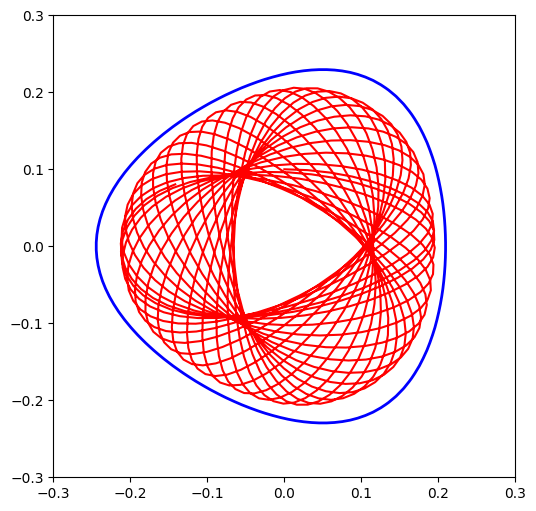

In [3]:
show_trajectory([0,0.1,0.2,0], t_max=150, R=0.3)

Plot of trajectory with initial conditions $[0, 0.1, 0.2, 0]$.

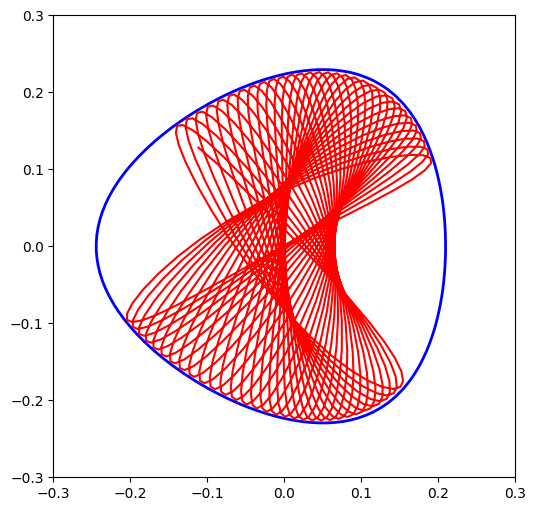

In [4]:
show_trajectory([0, 0, 0.2, 0.1], t_max=200, R=0.3)

Plot of tradjectory starting with initial conditions $[0, 0, 0.2, 0.1]$.

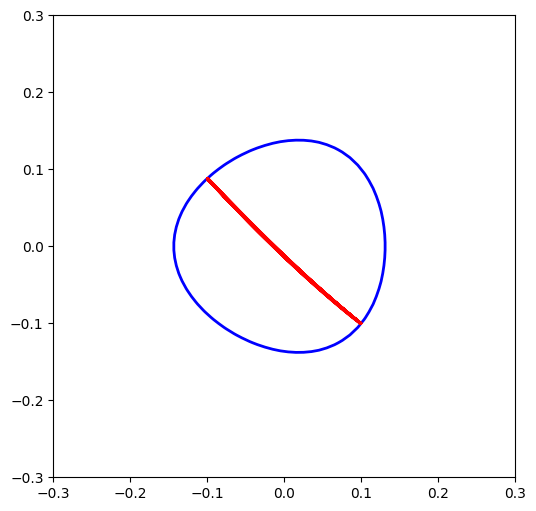

In [5]:
show_trajectory([0.1, -0.1, 0, 0], t_max=100, R=0.3)

# A periodic orbit

Plot of trajectory with initial conditions $[0.1, -0.1, 0, 0]$. This shows the trajectory "rocking back and fourth" along the same line: a periodic orbit. The other graphs show a nice oscillatory pattern.

These are all plots where the energy of the trajectory is below $E_0 = 1/6$. This energy level is called the *escape energy*: it is the amount of energy required to escape the *chaotic saddle*<sup><a href="#ref1" id="cite1">1</a></sup> which is the region contained by the contour $V = 1/6$.

This red line is the equation $V = E_0$, where $V$ is the *potential* energy function in our system. We can argue that this line can never be crossed by a trajectory by a simple physical intuition. Along a trajectory, the total energy $E$, is split between potential energy $V$ and kinetic energy, $T$. As our trajectory approaches the blue contour, it's potential energy must approach $E_0$. We know that energy is conserved in our system, so the maximum $V$ can be is $E_0$, at which point all of the particle's energy is potential and it is not moving. So the particle cannot physically cross the line, and if at this point the particle is not in a stable position, then the only direction it could continue moving is back the way it came, giving us the effect of the particle rolling up the surface and then back down.

We can think of this system as a ball rolling around the surface described by $V$. As the ball rolls, the energy moves between potential and kinetic energy. At the point where all the ball's energy is potential, it cannot gain more potential energy and must start converting energy back into kinetic, hence rolling back down the surface.

##### Task 2.3: Escape Trajectories

In [6]:
def show_trajectory_fancy(u0: list[float], t_max: float=50, t_steps: int=2000, R: float=1.5, ax=None):
    """
    Plot trajectory with additional formatting, as requested.

    :param List[float] u0: The initial values [x, y, p, q]
    :param float t_max: The max time to simulate to
    :param int t_steps: Granularity of visualisation (time)
    :param float R: Radius of circle to clip contours to
    :param ax: Optional matplotlib axis to plot on (if None, 
    a new figure is created)
    """
    if ax is None:
        fig, ax = plt.subplots()

    sol = solve(u0, t_max=t_max, t_steps=t_steps)

    x = sol.y[0]
    y = sol.y[1]

    # Energy at initial point
    E_init = energy(u0)

    # Circle boundary 
    circle = plt.Circle((0, 0), R, edgecolor='black', facecolor='none', linestyle='--')
    ax.add_patch(circle)

    # V contours
    grid_n = 300
    X = np.linspace(-R, R, grid_n)
    Y = np.linspace(-R, R, grid_n)
    X, Y = np.meshgrid(X, Y)
    Z = V(X, Y)

    c = np.linspace(Z.min(), Z.max(), 10)
    c2 = np.linspace(0, E_init, 3)
    contours1 = ax.contour(X, Y, Z, levels=c, colors='lightgrey')
    contours2 = ax.contour(X, Y, Z, levels=c2, colors='lightgrey')
    e_init_contour = ax.contour(X, Y, Z, levels=[E_init], colors='red', linewidths=1.5)

    # Clip contours to the circle
    for contour in [contours1, contours2, e_init_contour]:
        contour.set_clip_path(circle)


    # Plot trajectory
    ax.plot(x, y, color='blue')

    # Plot trajectory start and end
    ax.scatter([x[0]], [y[0]], color='green', s=30, label='start')
    if sol.status == 1:
        ax.scatter([x[-1]], [y[-1]], color='orange', marker='x', label='escape')
    else:
        ax.scatter([x[-1]], [y[-1]], color='black', marker='x', label='end')

    # Formatting
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.set_aspect('equal')
    ax.set_title(f"x: {u0[0]}, y: {u0[1]}, p: {u0[2]}, q: {u0[3]}")
    ax.set_axis_off()

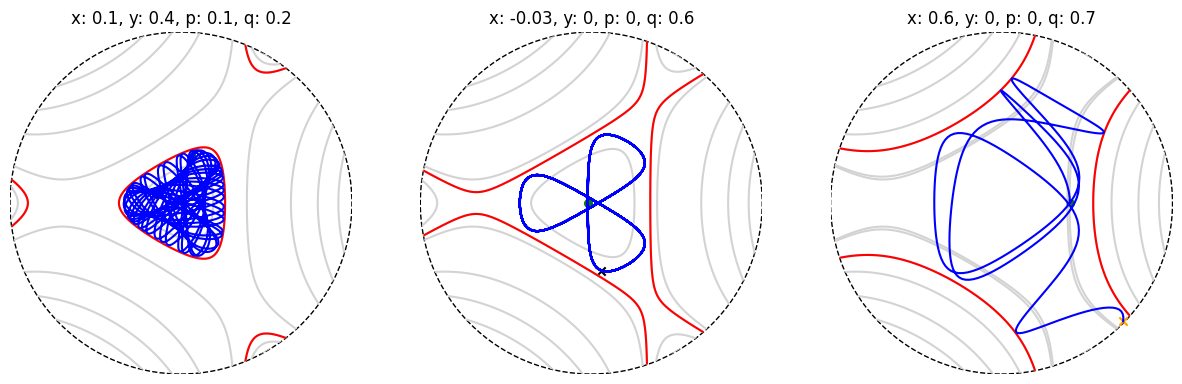

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

show_trajectory_fancy([0.1, 0.4, 0.1, 0.2], t_max=150, ax=axes[0])

show_trajectory_fancy([-0.03, 0, 0, 0.6], t_max=250, ax=axes[1])

show_trajectory_fancy([0.6, 0, 0, 0.7], t_max=150, ax=axes[2])

plt.show()

Above we can see three plots of trajectories with corresponding starting conditions displayed above each plot. These plots exhibit a number of different behaviours depending on the starting condition and particularly, the energy level of the starting condition. 

This system is called a *conservative Hamiltonian system* - conservative because the energy in the system is conserved throughout every point in a trajectory. This means that the energy is a function of only the starting condition, and not of time, and we can therefore calculate the energy of a given trajectory by taking the energy at the initial condition.

We see that there are a number of different scenarios for what happens to our trajectory. 

- When $E_0 < 1/6$ (the escape energy), and our trajectory is stuck in the *chaotic saddle* (image 1). Later, we go on to show that there exist islands of periodicity inside this chaotic saddle. 
- When we have enough energy, ($E_0 > 1/6$), the trajectory can fall into one of three sinks, and this is the behaviour exhibited by most starting conditions with enough energy. Despite this, we can still find the occasional periodic orbit with energy above $1/6$, as seen in image 2. In image 3, we see a trajectory diverging down the bottom right sink.

## Section 3

##### Task 3.1: A three-leaf clover

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar


def V_3(x, y):
    return 0.5*x**2 + 0.5*y**2 - x*y**2 + (1/3)*x**3

def T_3(p, q):
    return  0.5*p**2 + 0.5*q**2

def energy_3(u: list[float]) -> float:
    """
    Calculate energy

    :param List[float] u: List of parameters [x, y, p, q]
    :returns: Energy at point
    """
    x, y, p, q = u
    
    V_val = V_3(x, y)
    T_val = T_3(p, q)
    
    return V_val + T_val


def system_3(t: float, u: list[float]) -> list[float]:
    """System of derivatives for solve_ivp"""
    x, y, p, q = u
    
    dxdt = p
    dydt = q
    dpdt = y**2 - x**2 - x
    dqdt = 2*x*y - y
    
    return [dxdt, dydt, dpdt, dqdt]


def escape_3(t, u, R=1.5):
    """Event triggered when trajectory escapes circle of radius R"""
    x, y, p, q = u
    return R**2 - (x**2 + y**2)
escape_3.terminal=True


def y_cross(t, u):
    """Event triggered when trajectory crosses y=0"""
    return u[1]
    

def solve_3(u0: list[float], t_max: int=300, t_steps: int=10000):
    """
    Solve system of differential equations with given 
    initial conditions u0. Run simulations to the time t_max,
    where t_steps are made over the course of the simulation.

    :param List[float] u0: Initial conditions [x0, y0, p0, q0]
    :param float t_max: Max time to simulate to
    :param int t_steps: Number of time steps to evaluate at
    :returns: Solution object from solve_ivp
    """
    t_eval = np.linspace(0, t_max, t_steps)
    
    sol = solve_ivp(
        system_3,                
        [0, t_max],      
        u0,                     
        t_eval=t_eval,          
        rtol=1e-12, atol=1e-12,
        events=[escape_3, y_cross],
        max_step=0.1
    )
    
    return sol


def show_trajectory_fancy_3(u0, t_max=50, t_steps=2000, R=1.5, ax=None, title=""):
    """
    Plot trajectory with additional formatting, as requested. An upgraded
    version of the function from part 2.

    :param List[float] u0: The initial values [x, y, p, q]
    :param float t_max: The max time to simulate to
    :param int t_steps: Granularity of visualisation (time)
    :param float R: Radius of circle to clip contours to
    :param ax: Optional matplotlib axis to plot on (if None, 
    a new figure is created)
    :param title: Optional title for the plot
    """
    if ax is None:
        fig, ax = plt.subplots()

    sol = solve_3(u0, t_max=t_max, t_steps=t_steps)

    x = sol.y[0]
    y = sol.y[1]

    E_init = energy_3(u0)

    # Circle boundary 
    circle = plt.Circle((0, 0), R, edgecolor='black', facecolor='none', linestyle='--')
    ax.add_patch(circle)

    # Contour 
    grid_n = 300
    X = np.linspace(-R, R, grid_n)
    Y = np.linspace(-R, R, grid_n)
    X, Y = np.meshgrid(X, Y)
    Z = V_3(X, Y)

    c = np.linspace(Z.min(), Z.max(), 10)
    c2 = np.linspace(0, E_init, 3)

    contours1 = ax.contour(X, Y, Z, levels=c, colors='lightgrey')
    contours2 = ax.contour(X, Y, Z, levels=c2, colors='lightgrey')
    e_init_contour = ax.contour(X, Y, Z, levels=[E_init], colors='red', linewidths=1.5)

    # Clip contours to the circle
    for contour in [contours1, contours2, e_init_contour]:
        contour.set_clip_path(circle)


    # Plot trajectory
    ax.plot(x, y, color='blue')

    # Plot trajectory start and end
    ax.scatter([x[0]], [y[0]], color='green', s=30, label='start')
    if sol.status == 1:
        ax.scatter([x[-1]], [y[-1]], color='orange', marker='x', label='escape')
    else:
        ax.scatter([x[-1]], [y[-1]], color='black', marker='x', label='end')
    
    # Formatting
    initial_condition_text=f"x: {u0[0]}, y: {u0[1]}, p: {u0[2]}, q: {u0[3]}"
    ax.set_xlabel(initial_condition_text)

    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.set_aspect('equal')
    if title != "":
        ax.set_title(title)


def objective_function(x0_estimate: float, q0: float=0.6):
    """
    Objective function for finding estimate for x_0 that produces
    a periodic trajectory. This function returns
    the change in x_0 from the initial condition at
    the point where the trajectory crosses the x-axis for the 
    4th time. This corresponds to a 3 leafed clover.

    :param float x0_estimate: Initial x_0 value
    :param float q0: Initial q_0 value
    :returns: Difference in x_0 at moment of 4th
    x-axis crossing 
    """
    u0 = [x0_estimate, 0, 0, q0]

    sol = solve_3(u0, 1000)

    if len(sol.t_events[0]) > 0:
        raise ValueError("Trajectory escaped!")

    crossing_times = sol.t_events[1]
    crossing_states = sol.y_events[1]

    # Filter out the immediate trigger at t=0
    valid_indices = np.where(crossing_times > 1e-10)[0]

    fourth_crossing_time = valid_indices[3]
    state_at_4th_crossing = crossing_states[fourth_crossing_time]

    final_x = state_at_4th_crossing[0]

    # Return difference from new iteration to initial guess
    return final_x - x0_estimate


def find_clover():
    """
    Find the x0 value that produces a 3-leaf clover trajectory, using the
    objective function defined above and the root_scalar function from scipy.

    We are looking for a 3-leaf clover near the initial state [−0.03, 0, 0, 0.6].
    """

    diverged = False
    try:
        result = root_scalar(
            objective_function, 
            x0=-0.0299,         
            x1=-0.0301,       
            method='secant', 
            xtol=1e-14
        )
    except ValueError:
        diverged = True


    if diverged:
        print("Trajectory diverged")
    elif result.converged:
        print(f"Successfully found the periodic orbit!")
        print(f"Precise x0 (three-leaf clover): {result.root}")
    else:
        print("Root finder failed to converge.")


find_clover()

Successfully found the periodic orbit!
Precise x0 (three-leaf clover): -0.0307160543188747


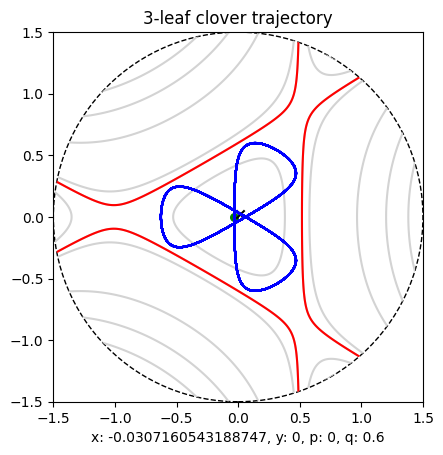

In [2]:
# Display calculated x value
show_trajectory_fancy_3([-0.0307160543188747, 0, 0, 0.6], t_max=300, title="3-leaf clover trajectory")

If we log the value of a trajectory every time it crosses a specific plane (in our case, $y = 0$), we are creating a *Poincaré map* (1-dimensional in our case). We wish to find the value of $x$ in the initial conditions of the system which mean that at the *fourth* time $y=0$, we return to the exact (to a tolerance) initial state. 

We opt to use scipy's `root_scalar` method for root finding here. We configure it to use the secant method as the Newton-Raphson method requires finding the derivative of the system which would be complicated. The secant method takes two initial guesses at $X_1$, $X_2$ and selects the $x$ value at the intersection between the line $X_1X_2$ and the $x$ axis. Running this method with an $x$ tolerance of $1e-14$ produces a $\hat{x}_0$ value of 
$$
\hat{x}_0 = -0.0307160543188747
$$

This should be an $x$ value which gives us a very tight clover up to $4$ crosses of the $x$ axis. As this is only an estimate, we shouldn't expect to use this value to find periodic clovers with more than $4$ $x$-axis crossings. To increase the number of crossings before our clover starts to drift, we can increase the number of crossings required before we take our estimate (demanding a higher `t_max`), and/or decreasing `xtol` in our `root_scalar` function (which means the solver will iterate to a higher degree of accuracy).

We now wish to find more clovers. Let's investigate whether initial states of the system in the form $[x_0, 0, 0, q_0]$ produce periodic clovers for some $\hat{x}_0 \approx x_0$, $\hat{q}_0 \approx q_0$.

In [3]:
from scipy.optimize import root


def objective_function_2d(estimates: list[float]):
    """
    Objective function for finding estimates x_0 and q_0
    that produce a periodic trajectory. This function returns
    the change in x_0 and q_0 from the initial condition at
    the point where the trajectory crosses the x-axis for the 
    4th time. This corresponds to a 3-leaf clover.

    :param List[float] estimates: [x_0, q_0], initial conditions for
    search
    :returns: Difference in state in x_0, q_0 at moment of 4th
    x-axis crossing
    """
    x_0_estimate, q_0_estimate = estimates

    u0 = [x_0_estimate, 0, 0, q_0_estimate]

    sol = solve_3(u0, 1000)

    # Error to escape if trajectory escaped
    if len(sol.t_events[0]) > 0:
        raise ValueError("Trajectory escaped!")


    crossing_times = sol.t_events[1]
    crossing_states = sol.y_events[1]

    # Filter out the immediate trigger at t=0
    valid_indices = np.where(crossing_times > 1e-10)[0]

    if len(valid_indices) < 4:
        raise ValueError("Trajectory did not pass section 4 times!")

    fourth_crossing_time = valid_indices[3]
    state_at_4th_crossing = crossing_states[fourth_crossing_time]

    x_final = state_at_4th_crossing[0]
    q_final = state_at_4th_crossing[3]

    return [x_final - x_0_estimate, q_final - q_0_estimate]


def find_3clover_xq(x_0: float, q_0: float):
    """
    Find a periodic orbit with initial condition
    [x_0, 0, 0, q_0] by slightly tweaking the given 
    values. Runs scipy.optimize.root to find the zeros
    to objective_function_2d.

    :param float x_0: Initial x
    :param float q_0: Initial q
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    show_trajectory_fancy_3([x_0, 0, 0, q_0], ax=axes[0], title="Initial trajectory")

    trajectory_diverged = False
    try:
        result = root(
            objective_function_2d, 
            x0=[x_0, q_0],
            method='hybr', 
            tol=1e-10
        )
    except ValueError:
        trajectory_diverged = True

    
    if trajectory_diverged:
        print("Trajectory diverged")
    elif result.status != 0:
        if result.success:
            print(f"Successfully found the periodic orbit!")
        
        print(f"Message: {result.message}")
        print(f"x0: {result.x[0]}")
        print(f"q0: {result.x[1]}")

        show_trajectory_fancy_3([result.x[0], 0, 0, result.x[1]], ax=axes[1], title="New trajectory")
    else:
        print(result.message)

# Expect ~1 min each for these.
# find_3clover_xq(-0.1, 0.55)
# find_3clover_xq(0, 0.4)
# find_3clover_xq(0, 0.6)
# find_3clover_xq(0, 0.55)  # Periodic, inside chaotic saddle!


The condition we are using to check for periodicity is called a *local Poincaré section*. This is the method of choice for determining if a trajectory is periodic, i.e., if it has returned back to it's initial state. The section acts to simplify this check by reducing the number of dimensions in which the validation must occur. We could for instance decide that a trajectory has returned to it's initial condition if it enters a small ball around that initial position. There are problems with this however, such as the possibility that the simulation "steps over" a short secant of the circle - which should be triggering the event. 

The local Poincaré section we use here is $y=0$. This is a lower dimensional slice out of our space and this makes it impossible to miss, given that our trajectory does not immediately diverge. As we are only working with initial conditions here that start on the $x$ axis with velocity perpendicular to the $x$ axis, our $y=0$ check is essentially a lax check that our trajectory is doing the same thing it was at the initial condition - it can be though of as a "finish line" for the trajectory. 

This idea can be extended to any initial condition. Given our initial condition we construct a plane (a line in our case) that passes directly through the initial position $(x_0, y_0)$. We then use our initial velocity $(p_0, q_0)$ to construct the plane perpendicular to the starting velocity. In our case we have velocity only in the $y$ direction, and our point is always on the $x$ axis, so the plane/line is $y=0$. We can use this extension to search for periodic orbits with any initial condition.

##### Task 3.2: Escape Basins

In [4]:
def categorise_trajectory(u0: list[float]) -> 0 | 1 | 2 | 3:
    """
    Categorises a trajectory into one of four categories:
    - 0: Does not diverge
    - 1: Diverges towards the left
    - 2: Diverges towards the top right
    - 3: Diverges towards the bottom right

    :param list[float] u0: Initial condition
    :returns: Integer corresponding to category
    :rtype: 0 | 1 | 2 | 3
    """

    solution = solve_3(u0, t_max=1000)

    if solution.status == 0:
        return 0
    
    escape_state = solution.y_events[0][0] 
    
    x_escape = escape_state[0]
    y_escape = escape_state[1]


    if x_escape < 0:
        return 1
    elif y_escape > 0:
        return 2 
    else:
        return 3


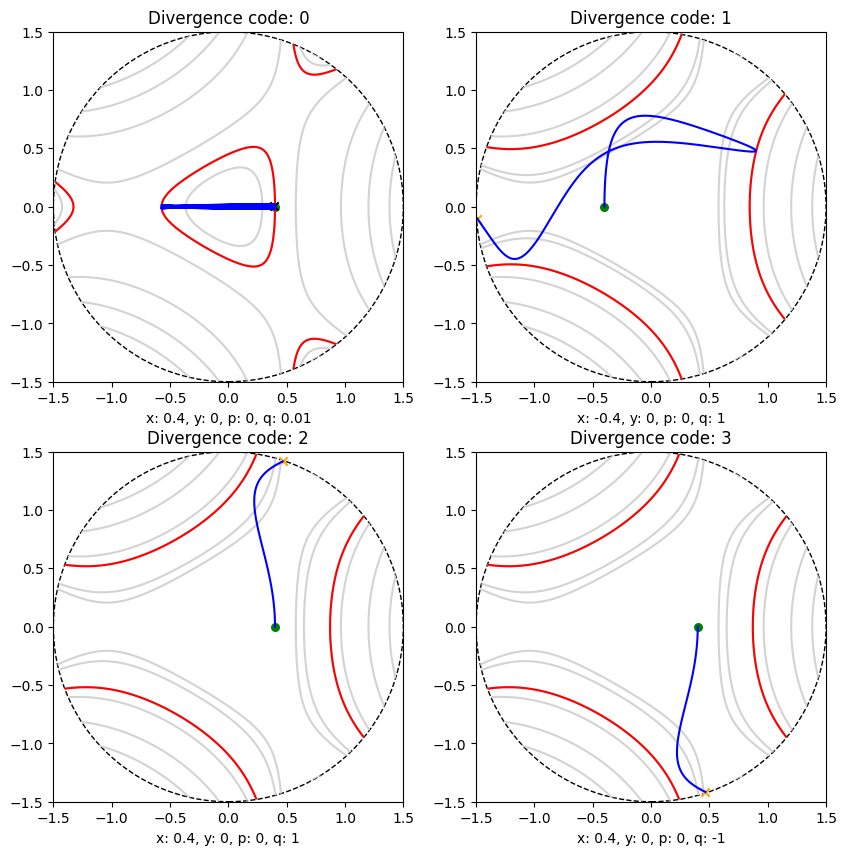

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# ---- Tests ----
## Does not diverge
u0_0 = [0.4, 0, 0, 0.01]
category_0 = categorise_trajectory(u0_0)
show_trajectory_fancy_3(u0_0, ax=axes[0, 0], title=f"Divergence code: {category_0}")

## Left
u0_1 = [-0.4, 0, 0, 1]
category_1 = categorise_trajectory(u0_1)
show_trajectory_fancy_3(u0_1, ax=axes[0, 1], title=f"Divergence code: {category_1}")

## Top right
u0_2 = [0.4, 0, 0, 1]
category_2 = categorise_trajectory(u0_2)
show_trajectory_fancy_3(u0_2, ax=axes[1, 0], title=f"Divergence code: {category_2}")

## Bottom right
u0_3 = [0.4, 0, 0, -1]
category_3 = categorise_trajectory(u0_3)
show_trajectory_fancy_3(u0_3, ax=axes[1, 1], title=f"Divergence code: {category_3}")

In [6]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


def create_exit_basin_plot(n: int=100):
    """
    Creates a plot on the xq-plane showing the exit direction 
    of the trajectory [x, 0, 0, q]. Each of the three exit basins
    are given a colour, and the basin the trajectory leaves from
    is determined by categorise_trajectory. Expect this algorithm
    to take a long time to run for large n.

    :param int n: Number of points to sample in each dimension
    """

    xs = np.linspace(-1, 0.5, n)
    qs = np.linspace(0.5, 1, n)
    
    X, Q = np.meshgrid(xs, qs)

    C = np.empty_like(X, dtype=int)

    # Iterate all pixels
    for i in range(n):
        for j in range(n):
            u0 = [X[i, j], 0, 0, Q[i, j]]
            C[i, j] = categorise_trajectory(u0)


    cmap = ListedColormap([
        "black",   
        "#82B2E6",
        "#BF62E3", 
        "#F58518"
    ])
    labels = [
        "0: bounded",
        "1: left divergence",
        "2: top right divergence",
        "3: bottom right divergence"
    ]

    # Create legend patches
    patches = [
        mpatches.Patch(color=cmap(i), label=labels[i])
        for i in range(4)
    ]

    plt.figure()
    plt.pcolormesh(X, Q, C, cmap=cmap, shading='auto')

    # Plot escape energy contour
    Z_simple = 0.5 * X**2 + (1/3) * X**3 + 0.5 * Q**2
    plt.contour(X, Q, Z_simple, levels=[1/6], colors='red')

    plt.xlabel("x")
    plt.ylabel("q")
    plt.title("Exit Basin Plot")
    plt.legend(handles=patches, loc="upper right", prop={'size': 7})

    plt.show()

    # Save the computed data
    # np.savez('exit_basin_data.npz', X=X, Q=Q, C=C, Z=Z_simple)


"""
create_exit_basin_plot(500)

Render dimensions: 500x500
Render duration: 452 minutes
CPU: Intel Core i7-12700 (12th gen)
"""

'\ncreate_exit_basin_plot(500)\n\nRender dimensions: 500x500\nRender duration: 452 minutes\nCPU: Intel Core i7-12700 (12th gen)\n'

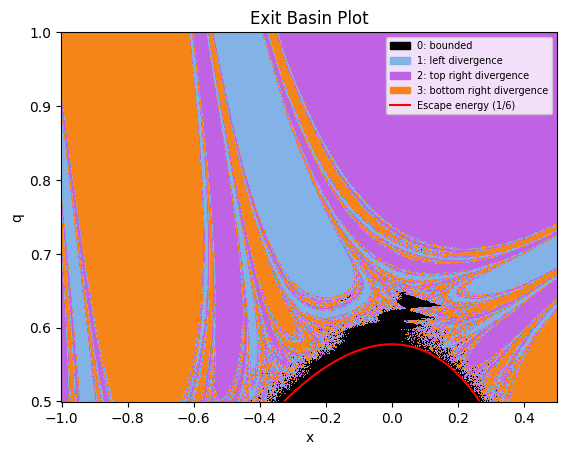

Above is a high resolution plot of the exit basin categorisations varying $x$ and $q$ (the $y$ direction velocity). As we can see, this plot contains lots of fine detail, and exhibits a fractal quality. That is, the more we zoom into the boundaries between the colours in this plot the more detail we reveal.

In fact, this system exhibits an even more mind-bending property: the property of Wada. This means that every point on the boundary of one of the regions (purple, blue and orange) is touching the boundary of the other two regions. This was proven in 2001 by M. A. F. Sanjuán et al<sup><a href="#ref1" id="cite1">1</a></sup>. Consequently, the boundaries of the coloured regions are incredibly complicated as wherever we zoom into a point on the boundary on one colour, we must also see the other two colours brushing against that point.

Also plotted is a contour to show the escape energy ($E_0 = 1/6$). The plot nicely outlines the black area on the plot: those trajectories which are bounded because they do not have enough energy to escape the saddle. We expect there to be no coloured pixels inside this contour, as these trajectories do not have enough energy to escape into one of the three sinks.

There is a single lone black pixel to the top right of the large black region, somewhere in $0 < x < 0.2$ and $0.7 < q < 0.75$. Let's pick out that bounded trajectory and see what it looks like, along with some other black pixels.

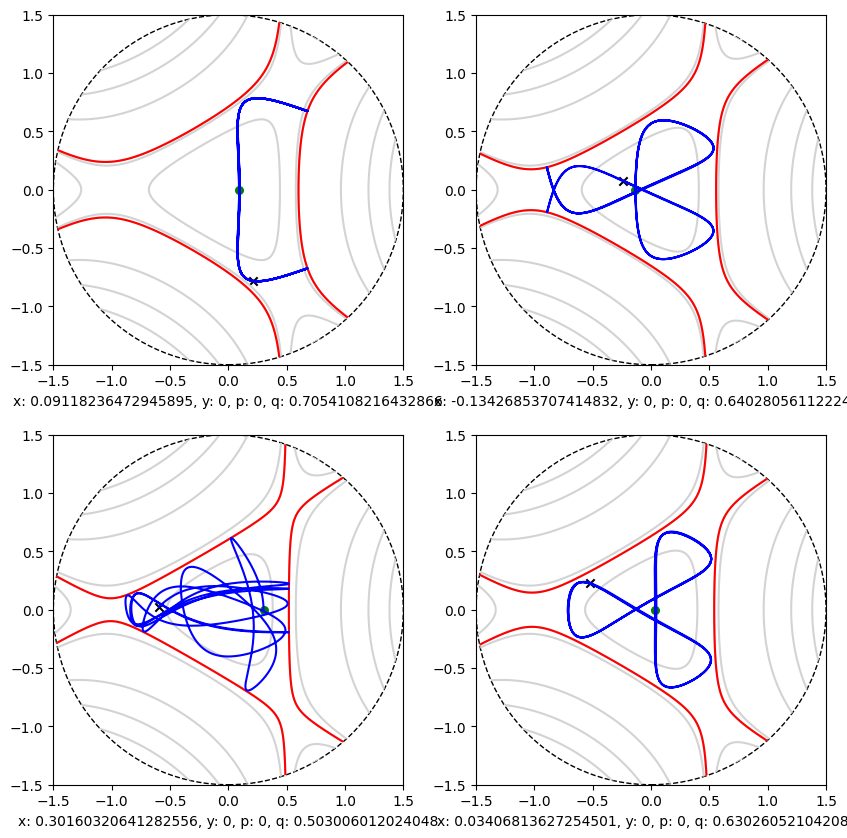

In [7]:
# Some periodic orbits observed from the graph above.

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Lone dot
show_trajectory_fancy_3([0.09118236472945895, 0, 0, 0.7054108216432866], ax=axes[0, 0])

# Another small island of periodic orbits. Top left of main blob
show_trajectory_fancy_3([-0.13426853707414832, 0, 0, 0.6402805611222445], ax=axes[0, 1])

# Lone dot on right of main blob, 3 pixels from q=0
show_trajectory_fancy_3([0.30160320641282556, 0, 0, 0.503006012024048], ax=axes[1, 0])

# Top spike of main black structure
show_trajectory_fancy_3([0.03406813627254501, 0, 0, 0.6302605210420842], ax=axes[1, 1])

This is most interesting - some periodic orbits unlike anything we've seen so far. 

##### Task 3.3: Extension: Lyapunov orbits

In this document we have been studying the [Hénon–Heiles system](https://en.wikipedia.org/wiki/H%C3%A9non%E2%80%93Heiles_system), rotated by 90° anticlockwise. It was introduced in 1964 by two astronomers Michel Hénon and Carl Heiles to study the dynamics of stars in a galaxy. 

In 2001, Miguel A. F. Sanjuán et al provided a detailed study of the system, including a proof of the property of Wada in it's exit basins. They also discuss *Lyapunov orbits*, which are unstable periodic orbits which constitute the boundary at which a particle is destined to fall into one of the three sinks. Given an energy level greater than the escape energy, typically $0.25$, the Lyapunov orbit at the "left" sink ("Exit 1" in the paper) can be found numerically. This can be used to find the other two via the rotational symmetry $2\pi/3$. 

With some modification to `objective_function`, we can verify the findings made by Miguel. We use a few insights in this computation.
1. We know that our trajectory passes through the $x$-axis, so we can set our initial condition to be $[x, 0, 0, q]$ where $q$ is determined by the energy level we choose.
2. As our system exhibits symmetry over the $x$-axis, the periodic orbit we are looking for must have no horizontal velocity component at the $x$-axis. This gives us a different variable to minimise, $q$ instead of the distance from $x$ to the next $x$ intersect of the trajectory. Supposedly this is better at finding orbits where the inputs are incredibly sensitive (chaotic orbits), as $x$ values retrieved from the objective function is incredibly sporadic, which does not work well with the root finding function.

Finding lyapunov for left sink with energy 0.25
Successfully found the lyapunov orbit!
x0 = -1.0246114627229692


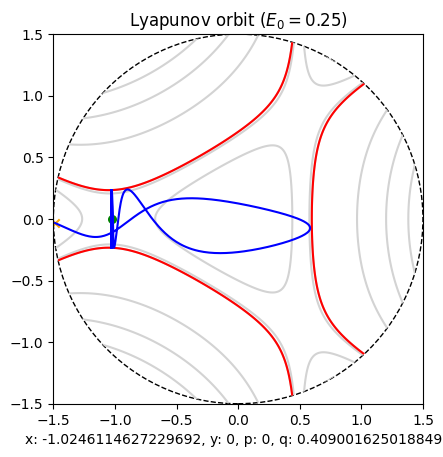

In [8]:
def get_objective_function_lyapunov(energy: float):
    """
    Factory function to get lyapunov objective function
    for a given energy.
    """

    def objective_function_lyapunov(x0):
        q0 = np.sqrt(2 * (energy - V_3(x0, 0)))

        u0 = [x0, 0, 0, q0]

        sol = solve_3(u0, 2000)

        crossing_times = sol.t_events[1]
        crossing_states = sol.y_events[1]

        # Filter out the immediate trigger at t=0
        valid_times = np.where(crossing_times > 1e-10)[0]

        if len(valid_times) < 1:
            # If it didn't even cross once, it slipped off the saddle immediately.
            # Return the final p to give the solver a continuous gradient.
            return sol.y[2, -1]

        first_crossing_time = valid_times[0]
        state_at_first_crossing = crossing_states[first_crossing_time]

        # Minimise p
        final_px = state_at_first_crossing[2] 
        return final_px

        # Minimise x difference
        #final_x = state_at_first_crossing[0]
        #return final_x - x0

    return objective_function_lyapunov


def find_lyapunov(E0: float=0.25, x0: float=-0.95) -> None:
    """
    Finds the Lyapunov orbit on the left sink. Fires trajectories
    [x, 0, 0, q], where q is a forced value by the provided energy
    level. We use a factory function to create an objective function
    specifically for the given energy value.

    :param float E0: Energy level to find the lyapunov orbit
    :param float x0: Initial guess for x0, near -1.
    """

    # This orbit only exists when the energy is above the escape energy
    if E0 < 1/6:
        print("Energy must be above the escape energy of 1/6 for a lyapunov orbit to exist.")
        return

    
    print(f"Finding lyapunov for left sink with energy {E0}")

    error = ""
    try:
        result = root_scalar(
            get_objective_function_lyapunov(E0),
            x0=x0,         
            x1=x0+1e-4,       
            method='secant', 
            xtol=1e-30
        )
    except ValueError as err:
        error = str(err)


    if error != "":
        print(error)
    elif result.converged:
        print(f"Successfully found the lyapunov orbit!")
        print(f"x0 = {result.root}")

        q_final = np.sqrt(2 * (E0 - V_3(result.root, 0)))

        show_trajectory_fancy_3([result.root, 0, 0, q_final], title=f"Lyapunov orbit ($E_0 = {E0}$)")
    else:
        print("Root finder failed to converge.")


find_lyapunov(E0=0.25)

The algorithm above reveals there is a Lyapunov orbit near the point $(-1.0246114627229692, 0)$. The paper by Mr Sanjuán has the Lyapunov orbit at $(0, 1.024611462679)$, which agrees with our result (remembering that our system is rotated 90° anticlockwise) to $9$ decimal places. Our algorithm does not seem capable of computing this value to a higher degree of accuracy - we may be reaching the limitations of inbuilt floating point arithmetic in Python here.

Something else of interest is whether we can "view" this Lyapunov orbit by creating a slightly modified version of our exit basin plot from task 3.2. The question we are asking is does this periodic orbit lie inside an "island" of other non-diverging trajectories. Mathematically put, given our computed orbit $x_0$, is there also another periodic orbit at $x_0 + \delta x$ for some small $\delta x \in \mathbb{R}\setminus \{0\}$?

To test this numerically, `xy_exit_basin_plot` plots an exit basin on the $xy$-plane. For each pixel $(x, y)$, the trajectory $[x, y, 0, q]$ is plotted, where $q$ is delineated by specifying an energy level. The function plots a region around the $x_0$ value computed above, based on a small value $\epsilon$. 

In [9]:
def xy_exit_basin_plot(epsilon: float=0.1, E0: float=0.25, n: int=100) -> None:
    """
    Render an exit basin plot on the xy-plane, zoomed around
    the x0 value computed in the previous part. Epsilon provides
    the size of the region around x0 to render. At each pixel (x, y),
    we compute the trajectory with initial condition [x, y, 0, q],
    where q is fixed by providing an energy level E0.

    :param float epsilon: Size of region around x0 to render
    :param float E0: Energy level to fix for computing q
    :param int n: Number of pixels in each dimension
    """

    x_center = -1.024611462679
    xs = np.linspace(x_center - epsilon, x_center + epsilon, n)
    ys = np.linspace(0-epsilon, 0+epsilon, n)
    
    X, Y = np.meshgrid(xs, ys)

    C = np.empty_like(X, dtype=int)

    for i in range(n):
        for j in range(n):
            x = X[i, j]
            y = Y[i, j]
            V_val = V_3(x, y)
            
            # Compute q using the energy function
            if V_val < E0:
                q0 = np.sqrt(2 * (E0 - V_val))
                u0 = [x, y, 0, q0]
                C[i, j] = categorise_trajectory(u0)
            else:
                C[i, j] = np.nan


    cmap = ListedColormap([
        "black",
        "#82B2E6",
        "#BF62E3", 
        "#F58518"
    ], N=4)
    labels = [
        "0: bounded",
        "1: left divergence",
        "2: top right divergence",
        "3: bottom right divergence"
    ]

    # Create legend patches
    patches = [
        mpatches.Patch(color=cmap(i), label=labels[i])
        for i in range(4)
    ]

    
    plt.figure()  # vmin, vmax important so mapping works correctly
    plt.pcolormesh(X, Y, C, cmap=cmap, shading='auto', vmin=0, vmax=3)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Exit Basin Plot (Zoomed around x={x_center}, epsilon={epsilon}, E0={E0})")
    plt.legend(handles=patches, loc="upper right", prop={'size': 7})

    plt.show()


# xy_exit_basin_plot(n=10)

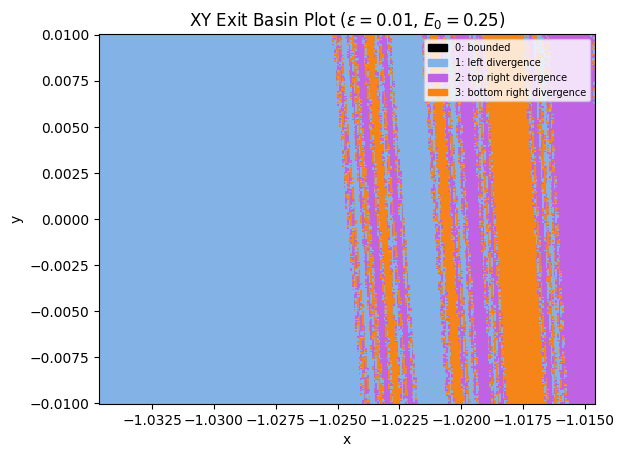

Interestingly, despite how far we zoom into this spot, we cannot find any black "bounded" pixels.

After some further investigation, it turns out that the reason we cannot find an island of periodic orbits is because of a general property of unstable periodic orbits. The value $x_0$ we are estimating is not apart of a larger connected set of periodic orbits. This is a similar phenomenon to how the rational numbers $\mathbb{Q}$ are "dense" in $\mathbb{R}$, but if we pick a random real number, there is a $0\%$ chance that we pick a rational number. This is therefore an exercise in futility. We could theoretically get a black pixel to appear, but this will only be a result of the physical limitations of our simulation - not a mathematical discovery.

## Acknowledgements

#### References
1. <a id="ref1"></a> M. A. F. Sanjuán et al - https://doi.org/10.1103/PhysRevE.64.066208
2. <a id="ref2"></a> https://www.youtube.com/watch?v=LjWvoJDAPuA
3. https://en.wikipedia.org/wiki/Chaos_theory

#### AI Use Disclosure

I used AI extensively in this project, to speed up the implementation of algorithms so I could focus on the mathematics. The bulk of my AI use was through a continuous dialogue with Google Gemini 3.1 Pro. My requests were a mixture between asking how to implement certain functions, to breakdowns of the mathematics happening behind the scenes. I also used the inbuilt VS Code AI agent (which defaulted to Grok 4.1 Fast) for a few quick tweaks.

- Google Gemini 3.1 Pro: assistance with coding tasks and help filling me in with the mathematics.
- VS Code AI Agent: small tweaks directly to code

## Appendix

Whilst deciding what to investigate in Task 3.3, I created a few more visualisations that seemed intriguing, find them below.

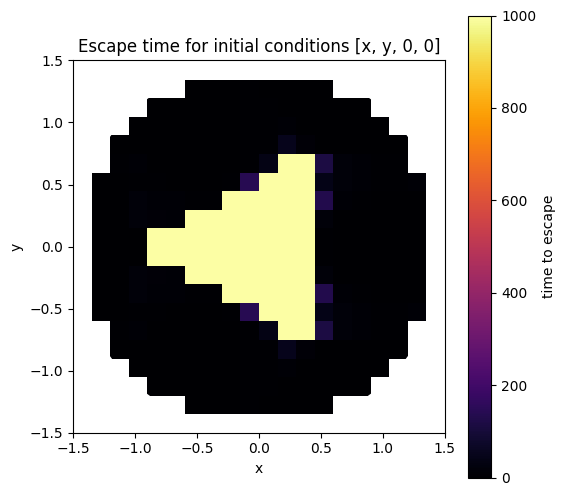

In [23]:
def escape_time(u0, t_max=100, t_steps=1000):
    sol = solve(u0, t_max=t_max, t_steps=t_steps)

    # If any events triggers, return that time
    if len(sol.t_events[0]) > 0:
        return sol.t_events[0][0]
    
    # Else return the maximum time
    return t_max


def time_to_divergence(R=1.5, n=10, t_max=100, t_steps=1000):
    xs = np.linspace(-R, R, n)
    ys = np.linspace(-R, R, n)

    T = np.full((n, n), np.nan)

    for i, x in enumerate(xs):
        for j, y in enumerate(ys):
            # Only calculate escape time for points within the circle of radius R
            if x**2 + y**2 <= R**2:
                T[j, i] = escape_time([x, y, 0, 0], t_max=t_max, t_steps=t_steps)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(
        T,
        extent=[-R, R, -R, R],
        origin="lower",
        cmap="inferno",
        interpolation="nearest",
        vmin=0,
        vmax=t_max,
    )
    circle = plt.Circle((0, 0), R, edgecolor="white", facecolor="none", linewidth=1.5)
    ax.add_patch(circle)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Escape time for initial conditions [x, y, 0, 0]")
    fig.colorbar(im, ax=ax, label="time to escape")
    plt.show()


time_to_divergence(R=1.5, n=20, t_max=1000, t_steps=1000)

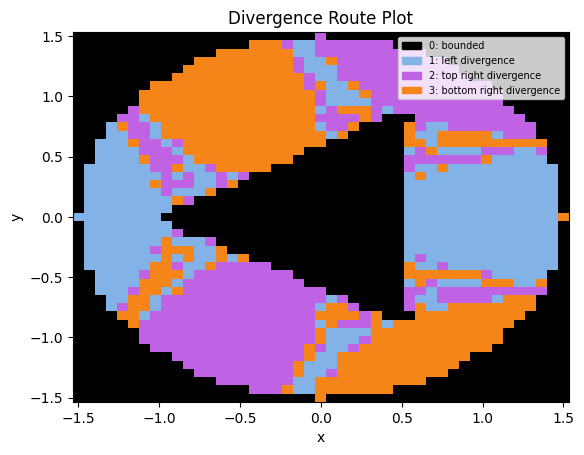

In [ ]:
def divergence_route(n=25, R=1.5):
    xs = np.linspace(-R, R, n)
    ys = np.linspace(-R, R, n)
    
    X, Y = np.meshgrid(xs, ys)

    C = np.empty_like(X, dtype=float)

    for i in range(n):
        for j in range(n):
            x = X[i, j]
            y = Y[i, j]
            if x**2 + y**2 <= R**2:
                u0 = [X[i, j], Y[i, j], 0, 0]
                C[i, j] = categorise_trajectory(u0)


    cmap = ListedColormap([
        "black",   
        "#82B2E6",
        "#BF62E3", 
        "#F58518"
    ])
    labels = [
        "0: bounded",
        "1: left divergence",
        "2: top right divergence",
        "3: bottom right divergence"
    ]

    # Create legend patches
    patches = [
        mpatches.Patch(color=cmap(i), label=labels[i])
        for i in range(4)
    ]


    plt.figure()
    plt.pcolormesh(X, Y, C, cmap=cmap, shading='auto')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Divergence Route Plot")
    plt.legend(handles=patches, loc="upper right", prop={'size': 7})

    plt.show()


divergence_route(45)